Makemore NLP Language Model

This project is similar to the previous in the sense that its using the same data set and has the same task of predicting the next character. However, instead of only taking the previous character as context for predicting the next, we will increase the context length to N (typically N=3). Additionally, the architecture of the model will be slightly more complicated, instead of a single matmul we will design a Multi-Layer Perceptron Model


Step 1: Imports, read names.txt, and build chars,stoi,itos (as previously done)

In [4]:
import torch, torch.nn.functional as F, matplotlib.pyplot as plt

words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

print(len(words), words[:5])
print(stoi)
print(itos[5])
print(chars[:5])

32033 ['emma', 'olivia', 'ava', 'isabella', 'sophia']
{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
e
['a', 'b', 'c', 'd', 'e']


Previously the dataset was a list of pairs (prev_char, next_char). Now its a list of pairs (Prev_N_chars, next_char), where N= block_size. Lets start .emma. as an example. (..., e) -> (..e,m) -> (.em, m) -> (emm,a) -> (mma, .). Notice, since the word length is 4, for a couple of the examples we needed to pad with '.'. Now lets create this dataset

In [5]:
block_size = 3
X, Y = [], []

for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X=torch.tensor(X)
Y=torch.tensor(Y)

print(X.shape, X.dtype)
print(Y.shape, Y.dtype)
print(X[:10])
print(Y[:10])

for x,y in zip(X[:20], Y[:20]):
     print(''.join(itos[i.item()] for i in x), '-->', itos[y.item()])


torch.Size([228146, 3]) torch.int64
torch.Size([228146]) torch.int64
tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22]])
tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9])
... --> e
..e --> m
.em --> m
emm --> a
mma --> .
... --> o
..o --> l
.ol --> i
oli --> v
liv --> i
ivi --> a
via --> .
... --> a
..a --> v
.av --> a
ava --> .
... --> i
..i --> s
.is --> a
isa --> b


Step 2: Create the lookup table (embedding table).

We want an embedding for each of the 27 characters. Therefore, we will have 27 rows. For now, lets assume each embedding is 2-Dimensional. Therefore, the lookup table will have shape (27,2). Initially, these will be random numbers

In [43]:
C=torch.randn((27,2), requires_grad=True)
emb = C[X]

print(C.shape)
print(emb.shape)
print(emb[0])
print(emb[0,0])
print(C[X[0,0]])

torch.Size([27, 2])
torch.Size([228146, 3, 2])
tensor([[-0.8538,  0.7189],
        [-0.8538,  0.7189],
        [-0.8538,  0.7189]], grad_fn=<SelectBackward0>)
tensor([-0.8538,  0.7189], grad_fn=<SelectBackward0>)
tensor([-0.8538,  0.7189], grad_fn=<SelectBackward0>)


The lookup table has a 2-Dimensional embedding for each of the characters. Therefore the embedding for one character has the shape (2,). If we take a single data point which has 3 characters, each character has its own vector embedding hence the shape of the vector embedding for one data point becomes (3,2). Therefore for the whole dataset of N examples, all these examples are stacked to create a shape (N,3,2)

Step 3: Flatten + Hidden Layer

After the lookup table, the next layer of the MLP is the hidden layer (w1x1 + w2x2 + w3x3.... wNxN + bias). However, the issue that we have now is that our input is 3-Dimensional (N,3,2). Which means, before applying the weights (matmul), we need to flatten it into a 2-Dimensional input

First we start with flattening, the 3-Dimensional input. Take it from (N,3,2) -> (N,6)

In [7]:
x=emb.view(-1,6)

Then we build the hidden layer of the MLP. Recall that we first multiply by a set of weights, then we add the biases, then we run it through a nonlinearity (lets assume its tanh).

In [44]:
n_hidden = 100
W1=torch.randn(6,n_hidden, requires_grad=True)
b1=torch.randn(n_hidden, requires_grad=True)

h=torch.tanh(x @ W1 + b1)

h.shape

torch.Size([182625, 100])

Now, the output layer. Previously, we took the initial 6 features up to 100 through the 100 neurons. Now, we want to take the features down to 27, hence our second layer of neurons will have 27 neurons.

In [45]:
n_hidden2 = 27
W2=torch.randn(n_hidden,n_hidden2, requires_grad=True)
b2=torch.randn(n_hidden2, requires_grad=True)

logits = h @ W2 + b2

logits.shape

torch.Size([182625, 27])

Now, the 27 outputs that we have are raw, unbounded scores (What we call logits), theyre not probabilities yet. We want to turn them into probabilities. We can do this by taking each output and first turning them all positive, we can do this through the exponential function, then we divide it by the sum of all the outputs (We did something similar in Bigram model). P = N.float() / N.sum(1, keepdim=True)


In [10]:
counts = torch.exp(logits)
P = counts / counts.sum(1, keepdim=True)


In [11]:
correct_probs = P[torch.arange(Y.shape[0]),Y]

neg_log = -torch.log(correct_probs)
mean_neg_log = torch.mean(neg_log)

print(mean_neg_log)


tensor(15.9150, grad_fn=<MeanBackward0>)


Now, we have a full working forward pass with an initial loss of 17.4117. Now, we need to run a backward pass and iteratively change the weights to reduce this overall loss

Step 4: Whole learning loop.

let's create a whole learning loop. Instead of manually computing the loss, we can directly use the F.cross_entropy() function to replace our manual computation of the loss.

In [12]:
num_iterations = 100
learning_rate = 1

for k in range(num_iterations):
    #Forward Pass
    emb = C[X]
    x = emb.view(-1,6)
    h=torch.tanh(x @ W1 + b1)
    logits = h @ W2 + b2


    #Loss
    mean_neg_log = F.cross_entropy(logits, Y)

    #Backward Pass
    mean_neg_log.backward()


    #Update
    C.data += learning_rate * -C.grad
    W1.data += learning_rate * -W1.grad
    W2.data += learning_rate * -W2.grad
    b1.data += learning_rate * -b1.grad
    b2.data += learning_rate * -b2.grad
    C.grad.zero_()
    W1.grad.zero_()
    W2.grad.zero_()
    b1.grad.zero_()
    b2.grad.zero_()

    #Logging
    print((k,mean_neg_log.item()))


(0, 15.91501235961914)
(1, 12.977131843566895)
(2, 8.780878067016602)
(3, 10.04935359954834)
(4, 11.919879913330078)
(5, 10.117011070251465)
(6, 10.250234603881836)
(7, 9.126642227172852)
(8, 8.638871192932129)
(9, 7.735485553741455)
(10, 6.081920146942139)
(11, 7.047473430633545)
(12, 8.906746864318848)
(13, 8.797473907470703)
(14, 9.068769454956055)
(15, 6.771618366241455)
(16, 5.964931488037109)
(17, 7.096127986907959)
(18, 6.799829483032227)
(19, 6.756088733673096)
(20, 6.599440097808838)
(21, 6.447207927703857)
(22, 8.136578559875488)
(23, 7.533954620361328)
(24, 6.073598861694336)
(25, 5.855931758880615)
(26, 6.731290340423584)
(27, 5.666883945465088)
(28, 6.058008193969727)
(29, 5.00963020324707)
(30, 4.239439487457275)
(31, 4.984134197235107)
(32, 7.243091106414795)
(33, 7.781111717224121)
(34, 5.9338226318359375)
(35, 6.070113658905029)
(36, 6.865860462188721)
(37, 5.837582588195801)
(38, 4.595109462738037)
(39, 4.064608573913574)
(40, 4.8465657234191895)
(41, 5.49789047241210

Step 5: Introduce Mini-Batches

Now, instead of running one piece of data through the dataset, running a backward pass, and then tuning the weights we will run minibatches of the data. The advantage of doing this is to speed up the learning process. Although the gradients will be less accurate since we will only be looking at a small portion of the data, it allows us to take faster (although less accurate) steps towards the minimal loss. To start, lets assume a mini-batch of 32

In [13]:
num_iterations = 1000
learning_rate = 1

for k in range(num_iterations):

    #Mini-batch
    ix = torch.randint(0, X.shape[0], (32,))
    #Forward Pass
    emb = C[X[ix]]
    x = emb.view(-1,6)
    h=torch.tanh(x @ W1 + b1)
    logits = h @ W2 + b2


    #Loss
    mean_neg_log = F.cross_entropy(logits, Y[ix])

    #Backward Pass
    mean_neg_log.backward()


    #Update
    C.data += learning_rate * -C.grad
    W1.data += learning_rate * -W1.grad
    W2.data += learning_rate * -W2.grad
    b1.data += learning_rate * -b1.grad
    b2.data += learning_rate * -b2.grad
    C.grad.zero_()
    W1.grad.zero_()
    W2.grad.zero_()
    b1.grad.zero_()
    b2.grad.zero_()

    #Logging
    print((k,mean_neg_log.item()))


(0, 3.474526882171631)
(1, 6.294988632202148)
(2, 6.690425872802734)
(3, 6.857142448425293)
(4, 8.465964317321777)
(5, 5.321777820587158)
(6, 7.554726600646973)
(7, 9.115994453430176)
(8, 8.702486991882324)
(9, 9.317051887512207)
(10, 8.522321701049805)
(11, 6.922572612762451)
(12, 7.378851413726807)
(13, 8.079330444335938)
(14, 7.337355613708496)
(15, 8.801511764526367)
(16, 8.546954154968262)
(17, 9.045867919921875)
(18, 6.956653594970703)
(19, 5.931394100189209)
(20, 6.526604652404785)
(21, 7.573038101196289)
(22, 7.7275590896606445)
(23, 6.617147445678711)
(24, 6.258619785308838)
(25, 5.902818202972412)
(26, 5.546802997589111)
(27, 6.8200554847717285)
(28, 6.3040852546691895)
(29, 7.103198528289795)
(30, 9.87451171875)
(31, 6.958534240722656)
(32, 5.102707386016846)
(33, 5.607611656188965)
(34, 7.250082969665527)
(35, 7.368581771850586)
(36, 6.9845805168151855)
(37, 7.298215866088867)
(38, 7.212271690368652)
(39, 7.669800758361816)
(40, 7.466062545776367)
(41, 6.484318733215332)
(4

Step 6: Introduce Learning rate fine tuning

Rather than guessing the best learning rate we will try to find the most optimal. What we will do is; We will run through a full 1000 iterations, at each iteration we sweep the learning rate from a pre-defined min to a pre-defined max (0.001 to 1) and we inspect the behaviour of the loss at each of the learning rate through a graph.

(0, 2.9965317249298096)
(1, 2.750861644744873)
(2, 2.7165772914886475)
(3, 3.0593550205230713)
(4, 2.8885772228240967)
(5, 3.087475061416626)
(6, 2.2244484424591064)
(7, 2.7245919704437256)
(8, 3.1131129264831543)
(9, 3.170945882797241)
(10, 2.7026617527008057)
(11, 2.7001559734344482)
(12, 2.5908312797546387)
(13, 3.1054153442382812)
(14, 3.2950656414031982)
(15, 2.879235029220581)
(16, 2.5915143489837646)
(17, 2.4607656002044678)
(18, 2.977354049682617)
(19, 2.6448373794555664)
(20, 3.24222993850708)
(21, 2.7781920433044434)
(22, 2.6595029830932617)
(23, 3.2549593448638916)
(24, 2.723889112472534)
(25, 2.91717529296875)
(26, 2.8108017444610596)
(27, 2.969433307647705)
(28, 2.9335007667541504)
(29, 2.9363811016082764)
(30, 2.5632312297821045)
(31, 2.8404648303985596)
(32, 2.582411289215088)
(33, 3.077989339828491)
(34, 2.789504051208496)
(35, 2.737982749938965)
(36, 2.858612537384033)
(37, 2.8241593837738037)
(38, 2.7898855209350586)
(39, 2.8452956676483154)
(40, 2.4908108711242676)
(

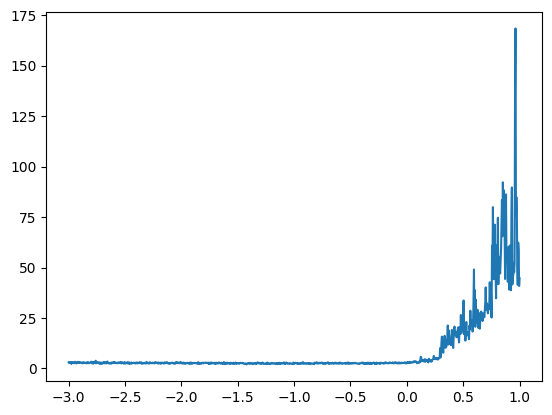

In [14]:
num_iterations = 1000
exps = torch.linspace(-3, 1, 1000)

xs,ys = [], []

for k in range(num_iterations):
    #Mini-batch
    ix = torch.randint(0, X.shape[0], (32,))
    #Forward Pass
    emb = C[X[ix]]
    x = emb.view(-1, 6)
    h = torch.tanh(x @ W1 + b1)
    logits = h @ W2 + b2

    #Loss
    mean_neg_log = F.cross_entropy(logits, Y[ix])

    #Backward Pass
    mean_neg_log.backward()

    #Learning rate
    learning_rate = 10 ** exps[k]

    #Update
    C.data += learning_rate * -C.grad
    W1.data += learning_rate * -W1.grad
    W2.data += learning_rate * -W2.grad
    b1.data += learning_rate * -b1.grad
    b2.data += learning_rate * -b2.grad
    C.grad.zero_()
    W1.grad.zero_()
    W2.grad.zero_()
    b1.grad.zero_()
    b2.grad.zero_()

    #Logging
    print((k, mean_neg_log.item()))

    xs.append(exps[k].item())
    ys.append(mean_neg_log.item())

plt.plot(xs,ys)

Step 7: Now, I will split the data into training/validation/test to actually evaluate the model, see whether it overfits to the training data. When splitting the data its important that I split by words rather than splitting by rows, the reason is that there is not data leakage. If we dont split by words, some parts of the word might be in training and others might be in validation.

In [30]:
import random

words = open('names.txt').read().splitlines()
random.seed(42)
random.shuffle(words)

n1=int(len(words)*0.8)
n2=int(len(words)*0.9)

train_words = words[:n1]
val_words = words[n1:n2]
test_words=words[n2:]


def build_dataset(words):

    block_size = 3
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X=torch.tensor(X)
    Y=torch.tensor(Y)

    return X,Y

Xtr,Ytr = build_dataset(train_words)
Xval,Yval = build_dataset(val_words)
Xtest,Ytest = build_dataset(test_words)


print(Xtr.shape)
print(Xval.shape)
print(Xtest.shape)


torch.Size([182625, 3])
torch.Size([22655, 3])
torch.Size([22866, 3])


Now we conduct the full training loop on the training data, we will implement it with the same 32 mini-batch method

In [31]:
num_iterations = 6000
learning_rate = 0.3

for k in range(num_iterations):

    #Mini-batch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    #Forward Pass
    emb = C[Xtr[ix]]
    x = emb.view(-1,6)
    h=torch.tanh(x @ W1 + b1)
    logits = h @ W2 + b2


    #Loss
    mean_neg_log = F.cross_entropy(logits, Ytr[ix])

    #Backward Pass
    mean_neg_log.backward()


    #Update
    C.data += learning_rate * -C.grad
    W1.data += learning_rate * -W1.grad
    W2.data += learning_rate * -W2.grad
    b1.data += learning_rate * -b1.grad
    b2.data += learning_rate * -b2.grad
    C.grad.zero_()
    W1.grad.zero_()
    W2.grad.zero_()
    b1.grad.zero_()
    b2.grad.zero_()

    #Logging
    print((k,mean_neg_log.item()))


(0, 17.064334869384766)
(1, 13.707221031188965)
(2, 11.865621566772461)
(3, 11.475517272949219)
(4, 9.457897186279297)
(5, 8.486678123474121)
(6, 10.498976707458496)
(7, 8.341245651245117)
(8, 7.041476726531982)
(9, 8.088233947753906)
(10, 7.651867389678955)
(11, 6.6057586669921875)
(12, 6.971576690673828)
(13, 7.052711486816406)
(14, 6.034747123718262)
(15, 5.376405239105225)
(16, 4.144248962402344)
(17, 5.385737895965576)
(18, 4.898780822753906)
(19, 5.075195789337158)
(20, 4.680093288421631)
(21, 5.71764612197876)
(22, 5.5953545570373535)
(23, 7.233266353607178)
(24, 5.750494480133057)
(25, 5.062927722930908)
(26, 4.998258590698242)
(27, 4.2231268882751465)
(28, 5.624444484710693)
(29, 3.9276020526885986)
(30, 5.94936990737915)
(31, 5.557412147521973)
(32, 5.047593593597412)
(33, 4.51685905456543)
(34, 4.20438289642334)
(35, 3.7693467140197754)
(36, 4.361309051513672)
(37, 4.177066326141357)
(38, 3.7524452209472656)
(39, 4.698291778564453)
(40, 4.115891456604004)
(41, 4.072259902954

Now we will run a forward pass on the validation data to compare the loss between the validation and training data. We will run the forward pass of the full data (not the mini-batches)

In [32]:
#Forward Pass
emb = C[Xval]
x = emb.view(-1,6)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Yval)

print(mean_neg_log.item())


#Forward Pass
emb = C[Xtr]
x = emb.view(-1,6)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Ytr)

print(mean_neg_log.item())

2.5801126956939697
2.5872983932495117


Because the training loss and the validation loss are essentially the same this suggests that there might be some underfitting which suggests that we should increase the size of the model. Hence, a new model will be built with an increased size of hidden layer

In [46]:
import random
num_iterations = 15000
learning_rate = 0.3
n_hidden = 300
n_hidden2 = 27


W1=torch.randn(6,n_hidden, requires_grad=True)
b1=torch.randn(n_hidden, requires_grad=True)


W2 = torch.randn(n_hidden, n_hidden2, requires_grad=True)
b2 = torch.randn(n_hidden2, requires_grad=True)


words = open('names.txt').read().splitlines()
random.seed(42)
random.shuffle(words)

n1=int(len(words)*0.8)
n2=int(len(words)*0.9)

train_words = words[:n1]
val_words = words[n1:n2]
test_words=words[n2:]


def build_dataset(words):

    block_size = 3
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X=torch.tensor(X)
    Y=torch.tensor(Y)

    return X,Y

Xtr,Ytr = build_dataset(train_words)
Xval,Yval = build_dataset(val_words)
Xtest,Ytest = build_dataset(test_words)


for k in range(num_iterations):
    #Mini-batch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    #Forward Pass
    emb = C[Xtr[ix]]
    x = emb.view(-1, 6)
    h = torch.tanh(x @ W1 + b1)
    logits = h @ W2 + b2

    #Loss
    mean_neg_log = F.cross_entropy(logits, Ytr[ix])

    #Backward Pass
    mean_neg_log.backward()

    #Update
    C.data += learning_rate * -C.grad
    W1.data += learning_rate * -W1.grad
    W2.data += learning_rate * -W2.grad
    b1.data += learning_rate * -b1.grad
    b2.data += learning_rate * -b2.grad
    C.grad.zero_()
    W1.grad.zero_()
    W2.grad.zero_()
    b1.grad.zero_()
    b2.grad.zero_()

    #Logging
    print((k, mean_neg_log.item()))



#Forward Pass
emb = C[Xval]
x = emb.view(-1,6)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Yval)

print(mean_neg_log.item())


#Forward Pass
emb = C[Xtr]
x = emb.view(-1,6)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Ytr)

print(mean_neg_log.item())




(0, 31.39735984802246)
(1, 26.953895568847656)
(2, 23.101146697998047)
(3, 23.249534606933594)
(4, 24.495115280151367)
(5, 23.659996032714844)
(6, 24.84665298461914)
(7, 15.831087112426758)
(8, 17.362173080444336)
(9, 18.227935791015625)
(10, 18.261415481567383)
(11, 17.805749893188477)
(12, 18.954986572265625)
(13, 17.935909271240234)
(14, 18.996273040771484)
(15, 17.033349990844727)
(16, 16.57148551940918)
(17, 14.642845153808594)
(18, 8.86508846282959)
(19, 11.949499130249023)
(20, 14.614459037780762)
(21, 14.906645774841309)
(22, 7.441826820373535)
(23, 15.35539436340332)
(24, 11.262004852294922)
(25, 12.290759086608887)
(26, 12.614624977111816)
(27, 11.85383415222168)
(28, 13.613022804260254)
(29, 11.766547203063965)
(30, 9.840597152709961)
(31, 8.79642391204834)
(32, 10.582182884216309)
(33, 9.29133129119873)
(34, 9.059781074523926)
(35, 9.918766021728516)
(36, 9.398909568786621)
(37, 9.323678016662598)
(38, 7.582897186279297)
(39, 9.564390182495117)
(40, 8.153985977172852)
(41, 

After increasing the size of the hidden layer it seems that the loss decreased by a negligible amount suggesting that the size of the hidden layer wasn't the limiting factor. The next step is to increase the embeddings dimensions

In [60]:
import random
num_iterations = 15000
learning_rate = 0.01
n_hidden = 300
n_hidden2 = 27


C=torch.randn((27,10), requires_grad=True)
emb = C[X]
x = emb.view(-1,30)



W1=torch.randn(30,n_hidden, requires_grad=True)
b1=torch.randn(n_hidden, requires_grad=True)


W2 = torch.randn(n_hidden, n_hidden2) * 0.01
W2.requires_grad = True
b2 = torch.zeros(n_hidden2, requires_grad=True)


words = open('names.txt').read().splitlines()
random.seed(42)
random.shuffle(words)

n1=int(len(words)*0.8)
n2=int(len(words)*0.9)

train_words = words[:n1]
val_words = words[n1:n2]
test_words=words[n2:]


def build_dataset(words):

    block_size = 3
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X=torch.tensor(X)
    Y=torch.tensor(Y)

    return X,Y

Xtr,Ytr = build_dataset(train_words)
Xval,Yval = build_dataset(val_words)
Xtest,Ytest = build_dataset(test_words)


for k in range(num_iterations):
    #Mini-batch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    #Forward Pass
    emb = C[Xtr[ix]]
    x = emb.view(-1, 30)
    h = torch.tanh(x @ W1 + b1)
    logits = h @ W2 + b2

    #Loss
    mean_neg_log = F.cross_entropy(logits, Ytr[ix])

    #Backward Pass
    mean_neg_log.backward()

    #Update

    learning_rate = 0.1 if k < 0.75 * num_iterations else 0.01
    C.data += learning_rate * -C.grad
    W1.data += learning_rate * -W1.grad
    W2.data += learning_rate * -W2.grad
    b1.data += learning_rate * -b1.grad
    b2.data += learning_rate * -b2.grad
    C.grad.zero_()
    W1.grad.zero_()
    W2.grad.zero_()
    b1.grad.zero_()
    b2.grad.zero_()

    #Logging
    print((k, mean_neg_log.item()))



#Forward Pass
emb = C[Xval]
x = emb.view(-1,30)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Yval)

print(mean_neg_log.item())


#Forward Pass
emb = C[Xtr]
x = emb.view(-1,30)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Ytr)

print(mean_neg_log.item())



(0, 3.3120408058166504)
(1, 3.1719563007354736)
(2, 3.126041889190674)
(3, 3.0360469818115234)
(4, 3.298234462738037)
(5, 2.878859519958496)
(6, 3.1793999671936035)
(7, 2.8966872692108154)
(8, 3.1128690242767334)
(9, 3.0712201595306396)
(10, 2.846860647201538)
(11, 3.149930238723755)
(12, 2.6863722801208496)
(13, 2.509366989135742)
(14, 2.7830231189727783)
(15, 2.968653917312622)
(16, 2.6622679233551025)
(17, 3.2102785110473633)
(18, 2.6785900592803955)
(19, 2.747026205062866)
(20, 3.1895511150360107)
(21, 2.9397940635681152)
(22, 2.804915428161621)
(23, 2.811699867248535)
(24, 2.883448362350464)
(25, 2.4499144554138184)
(26, 2.7484824657440186)
(27, 2.8421475887298584)
(28, 2.8573687076568604)
(29, 3.07877516746521)
(30, 2.75211238861084)
(31, 2.582737684249878)
(32, 3.0400354862213135)
(33, 2.7557461261749268)
(34, 2.6037914752960205)
(35, 2.708319664001465)
(36, 2.604205369949341)
(37, 2.7995758056640625)
(38, 2.689387083053589)
(39, 2.7260890007019043)
(40, 2.801920175552368)
(41, 

Notice that we above I also made some additional changes:
1.I scaled down the W2 and b2 beacuse the initial loss was at 32. Instead it should be at -log(1/27)=3.2 which suggests equal probability across each letter.
2.I implemented a learning rate decay

Now that the loss is reasonably good, lets run it once again the Test dataset and try to sample from the model

In [61]:
#Forward Pass
emb = C[Xtest]
x = emb.view(-1,30)
h=torch.tanh(x @ W1 + b1)
logits = h @ W2 + b2


#Loss
mean_neg_log = F.cross_entropy(logits, Ytest)

print(mean_neg_log.item())

2.1862666606903076


Given the loss of training ≈ Validation ≈ Test, it suggests that the model generalizes to data it hasn't seen and doesn't overfit its training data. Now, we will sample.

In [64]:
for _ in range(20): #Generate 20 names
    out = []
    context = [0] * block_size #Initialize context as three dots

    while True:
    #Forward pass on single current context
        emb = C[torch.tensor(context)]
        x = emb.view(-1,30) #Flatten -> (1, block_size * n_emb)
        h = torch.tanh(x @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        #Sample one index from the probability distribution
        ix = torch.multinomial(probs, 1).item()

        #Slide the window
        context = context[1:] + [ix]

        #Record ix in out, then stop if its the end token

        out.append(ix)

        if ix == 0:
            break

    print(''.join(itos[i] for i in out))





xomax.
jhenley.
vilya.
jaylahie.
cory.
cortriel.
aure.
nayah.
zixtarrayl.
sui.
lli.
ayon.
liya.
lorin.
shur.
seileigan.
ahi.
karrie.
maxiey.
cia.
